## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/evi2/
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)
Conversion: Development Seed (openEO-UDP project)


# Enhanced Vegetation Index 2 (EVI2) and openEO

Enhanced Vegetation Index 2 (EVI2) is a vegetation index derived from Sentinel-2 spectral bands. It is designed to improve vegetation signal in dense canopies and reduce the impact of soil background and atmospheric influences.

## Enhanced Vegetation Index (EVI2)

**EVI2** = 2.4 * (B08 - B04) / (B08 + B04 + 1.0)

- B08: Near-infrared (NIR)
- B04: Red

**Visualization:** The evalscript remaps EVI2 values to an RGB color palette using threshold ranges, enabling an intuitive interpretation from low to high vegetation signal.


## Import Required Libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [20]:
import openeo
import shapely
from PIL import Image
import matplotlib.pyplot as plt
from openeo.processes import array_create, if_

## Connect to Copernicus (CDSE) OpenEO Backend

Connect to the OpenEO backend and authenticate using OpenID Connect.

In [21]:
connection = openeo.connect(
    url="https://openeo.dataspace.copernicus.eu/"
).authenticate_oidc()

Authenticated using refresh token.


## Define Area of Interest

Define the spatial extent for our analysis. This example uses coordinates of Umag Town, Istria Coast, Croatia

In [22]:
spatial_extent = {"west" : 13.4986, "south" : 45.4166, "east" : 13.5876, "north" : 45.4558}

## Load Sentinel-2 Data

Load Sentinel-2 L2A (bottom-of-atmosphere reflectance) data.

In [ ]:
s2cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent= ["2025-05-12", "2025-05-13"],
    bands=["B08", "B04"],
)

# Avoid extra data
s2cube = s2cube.mask_polygon(
    shapely.geometry.box(
        minx=spatial_extent["west"],
        miny=spatial_extent["south"],
        maxx=spatial_extent["east"],
        maxy=spatial_extent["north"],
    )
)

# Take the first instance of the time dimension
s2cube = s2cube.reduce_dimension(dimension="t", reducer="first")

In [24]:
def enhanced_vegetation_index(data):
    B08, B04 = (data[0], data[1])

    # CDSE delivers Sentinel-2 L2A bands as digital numbers (0..10000)
    B08 = B08 / 10000
    B04 = B04 / 10000

    EVI2 = 2.4 * (B08 - B04) / (B08 + B04 + 1.0)

    stops = [
        (-1.1, [0, 0, 0]),
        (-0.2, [0.75, 0.75, 1]),
        (-0.1, [0.86, 0.86, 0.86]),
        (0.0, [1, 1, 0.88]),
        (0.025, [1, 0.98, 0.8]),
        (0.05, [0.93, 0.91, 0.71]),
        (0.075, [0.87, 0.85, 0.61]),
        (0.1, [0.8, 0.78, 0.51]),
        (0.125, [0.74, 0.72, 0.42]),
        (0.15, [0.69, 0.76, 0.38]),
        (0.175, [0.64, 0.8, 0.35]),
        (0.2, [0.57, 0.75, 0.32]),
        (0.25, [0.5, 0.7, 0.28]),
        (0.3, [0.44, 0.64, 0.25]),
        (0.35, [0.38, 0.59, 0.21]),
        (0.4, [0.31, 0.54, 0.18]),
        (0.45, [0.25, 0.49, 0.14]),
        (0.5, [0.19, 0.43, 0.11]),
        (0.55, [0.13, 0.38, 0.07]),
        (0.6, [0.06, 0.33, 0.04]),
    ]
    last_color = [0, 0.27, 0]

    rgb = last_color

    # Building the color chain from the highest threshold back to the lowest
    for threshold, color in reversed(stops):
        rgb = if_(EVI2 < threshold, color, rgb)

    return array_create(rgb)

In [25]:
EVI_image = s2cube.apply_dimension(
    dimension="bands",
    process=enhanced_vegetation_index
)

EVI_image = EVI_image.linear_scale_range(input_min=0, input_max=1, output_min=0, output_max=255)

EVI_image = EVI_image.save_result("PNG")

In [26]:
# Send job to backend and download the result
EVI_image.download("enhanced_vegetation_index.png")

## Visualize the result

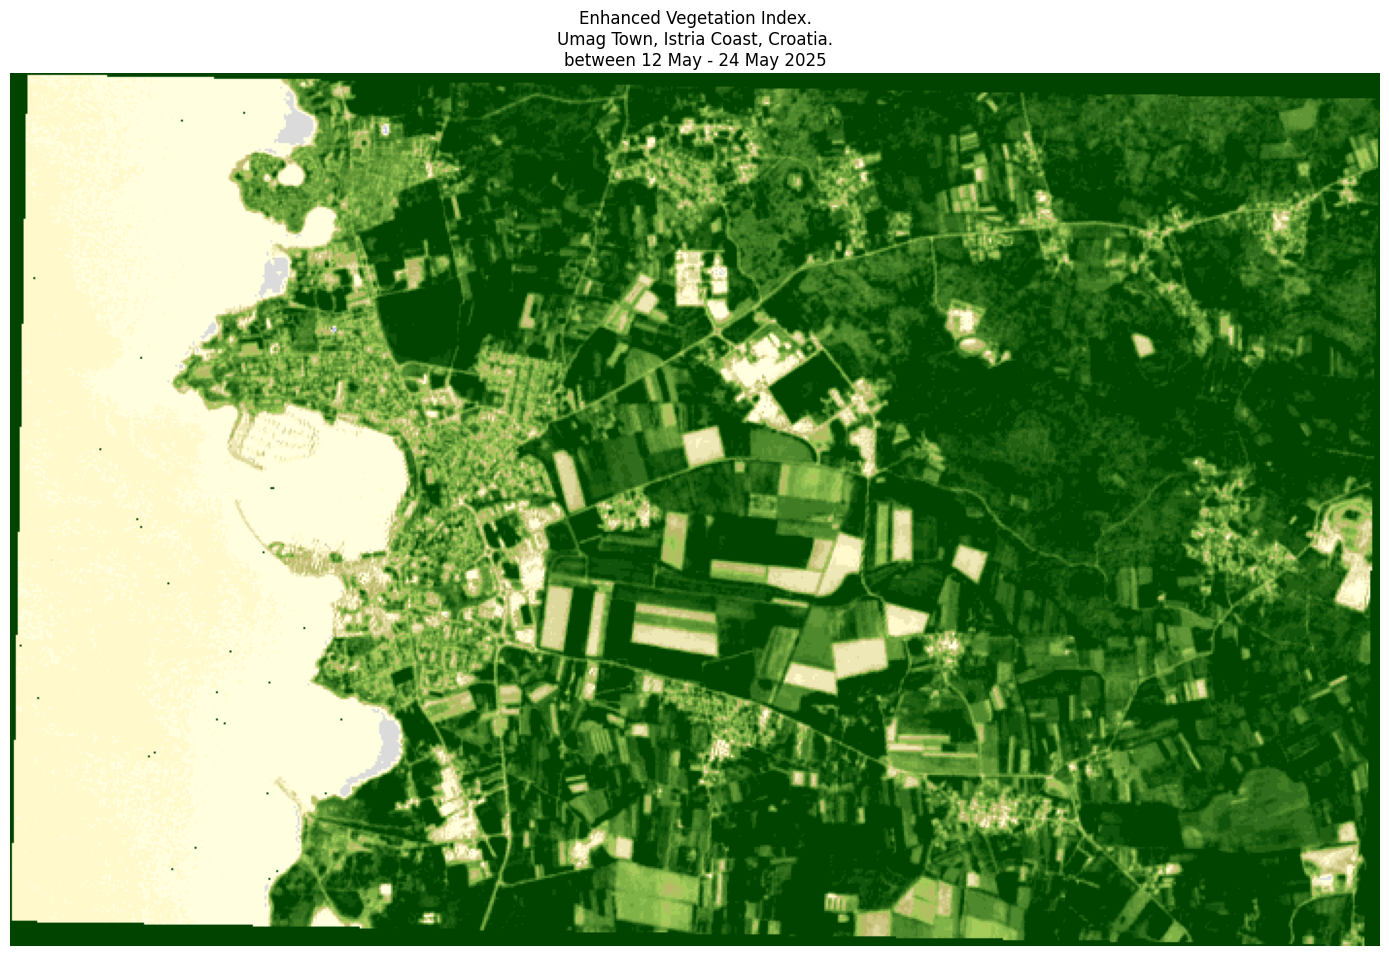

In [27]:
# Load and display the image
img = Image.open("enhanced_vegetation_index.png")

fig, ax = plt.subplots(figsize=(14, 10), dpi=100)
ax.imshow(img)
ax.set_title(
    "Enhanced Vegetation Index.\n"
    "Umag Town, Istria Coast, Croatia.\n"
    "between 12 May - 24 May 2025",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Interpretation Guide

### Reading EVI2 values

EVI2 is a **relative vegetation signal**: higher values mean greener/more vigorous vegetation, while low or negative values indicate bare soil, built-up surfaces, or very sparse vegetation.

Low values can also come from clouds, shadows, or water, so for cleaner maps you may want to apply additional masking for these features.

### Suggested improvement (optional)

In areas of dense canopy where the leaf area index (LAI) is high, indices like NDVI can be improved by leveraging information in the blue wavelength. Information in this portion of the spectrum can help correct for soil background signals and atmospheric influences.

### Visualization

The colors in this notebook come from a **fixed visualization palette** (thresholds mapped to specific RGB colors).

### Applications
- Vegetation monitoring: Rapidly highlighting areas of higher vs. lower vegetation activity
- Crop and land management: Comparing fields to spot variability or stress patterns
- Environmental change screening: Identifying areas that may warrant follow-up (e.g., drought impacts, land clearing, disturbance)

### Method overview
- The method compares how bright the surface appears in **near‑infrared (B08)** versus **red light (B04)**.
- Healthy, leafy vegetation usually reflects **more** near‑infrared and absorbs **more** red light, so EVI2 tends to be **higher** where vegetation is greener and more vigorous.
- To make the results easy to read as a map, EVI2 values are **grouped into ranges** and each range is shown with a **predefined RGB** (see the `stops` variable that shows the ranges' thresholds and their RGB map).

## Citation
The IDB Project. (2026). *Enhanced Vegetation Index 2 (EVI2) — IndexDatabase (IDB)*.  
IndexDatabase. https://www.indexdatabase.de/db/si-single.php?sensor_id=96&rsindex_id=237


## Attribution

This openEO User-Defined Process is a conversion of the original Sentinel Hub evalscript:

**Original Script:** [EVI2 (Enhanced Vegetation Index 2)](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/evi2/)

**Author:** (Author is not listed in the original script)

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

This conversion maintains the scientific methodology and visualization approach of the original evalscript while adapting it to the openEO process graph framework for interoperability across openEO-compliant backends.